In [1]:
import fastf1 as ff1
import seaborn as sns
from fastf1 import plotting
from matplotlib import pyplot as plt

%matplotlib widget

plotting.setup_mpl(mpl_timedelta_support=True, color_scheme="fastf1")

In [2]:
race = ff1.get_session(2025, 23, "R")
race.load()

req         WARNING 	DEFAULT CACHE ENABLED! (1.64 GB) C:\Users\Vitor\AppData\Local\Temp\fastf1


core           INFO 	Loading data for Qatar Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '55', '4', '12', '63', '14', '16', '30', '22', '23', '44', '5', '43', '31', '10', '18', '6', '87', '27']


In [3]:
point_finishers = race.drivers[:10]
point_finishers

['1', '81', '55', '4', '12', '63', '14', '16', '30', '22']

In [4]:
driver_laps = race.laps.pick_drivers(point_finishers).pick_quicklaps()
driver_laps = driver_laps.reset_index()

In [5]:
finishing_order = [race.get_driver(i)["Abbreviation"] for i in point_finishers]
finishing_order

['VER', 'PIA', 'SAI', 'NOR', 'ANT', 'RUS', 'ALO', 'LEC', 'LAW', 'TSU']

NameError: name 'fastf1' is not defined

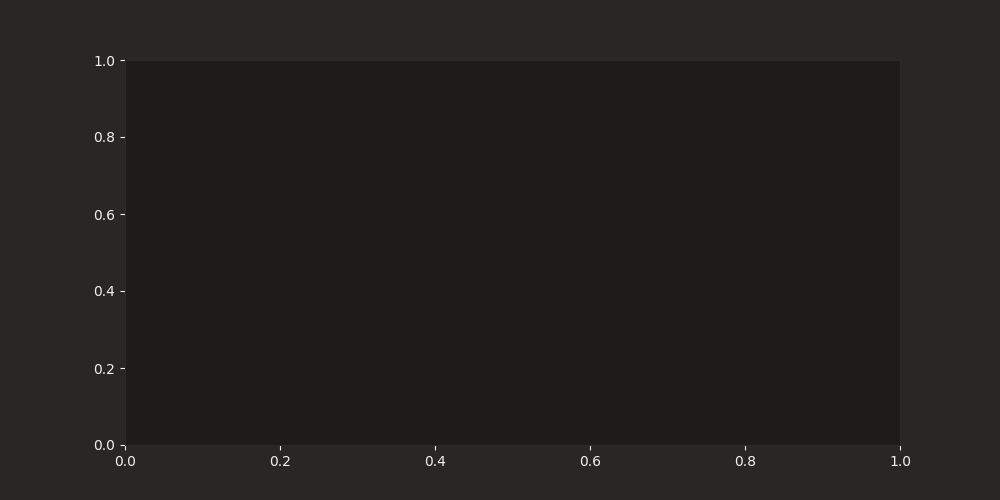

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

driver_laps["LapTime_s"] = driver_laps["LapTime"].dt.total_seconds()

sns.violinplot(
    data=driver_laps,
    x="Driver",
    y="LapTime_s",
    hue="Driver",
    inner=None,
    density_norm="area",
    order=finishing_order,
    palette=plotting.get_driver_color_mapping(session=race),
)

sns.swarmplot(
    data=driver_laps,
    x="Driver",
    y="LapTime_s",
    order=finishing_order,
    hue="Compound",
    palette=plotting.get_compound_mapping(session=race),
    hue_order=["SOFT", "MEDIUM", "HARD"],
    linewidth=0,
    size=4,
)

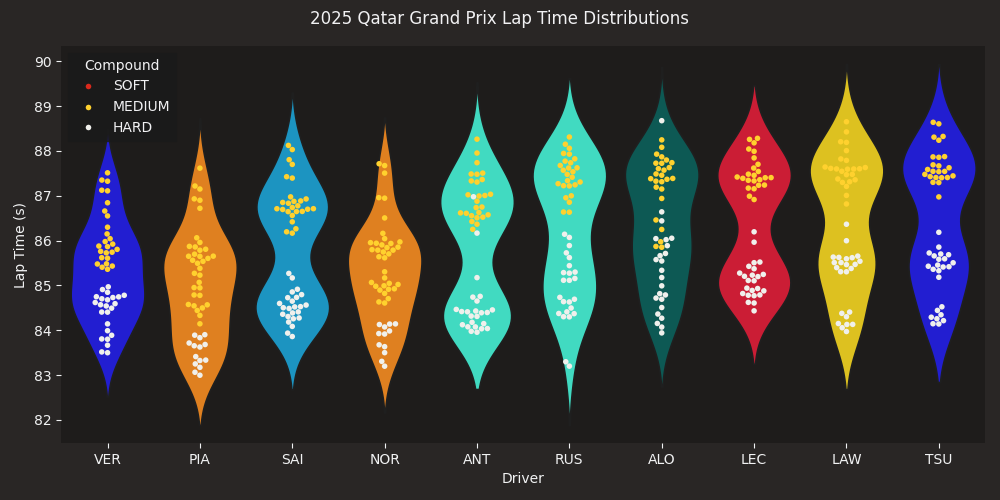

In [ ]:
ax.set_xlabel("Driver")
ax.set_ylabel("Lap Time (s)")
plt.suptitle("2025 Qatar Grand Prix Lap Time Distributions")
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()